## Synthoseis Quick Start Notebook

Synthoseis is an open source, Python-based tool used for generating pseudo-random seismic data. The goal of Synthoseis is to generate realistic seismic data for deep learning training. This notebook will serve as a guide to getting your first Synthoseis model up and running. Future notebooks will discuss seismic outputs, visualizations, and building a custom rock properties model.

### Environment Build

To install the necessary packages, use the `environment.yml` file to create a virtual or conda environment. Please note that the most recent version of Synthoseis has been refactored to work with Python 3.10.

### Imports

Within the main directory of the repo is a script called `main.py`. This is the primary script to run the program. Import `main.py`, along with visualization tools to view the results.

In [5]:
import os
import sys
from pathlib import Path

# Add repository top-level (where main.py or .git lives) to sys.path so `import main` works
p = Path().resolve().parent
sys.path.insert(0, str(p))
p
# repo_root = None
# for parent in [p] + list(p.parents):
#   if (parent / 'main.py').exists() or (parent / '.git').exists():
#     repo_root = parent
#     break
# if repo_root is None:
#   repo_root = p  # fallback
# sys.path.insert(0, str(repo_root))

# # Optionally expose to PYTHONPATH for subprocesses
# os.environ.setdefault("PYTHONPATH", str(repo_root) + (os.pathsep + os.environ["PYTHONPATH"] if os.environ.get("PYTHONPATH") else ""))

PosixPath('/home/gavargas/Developer/synthoseis')

In [7]:
import main as mn
import numpy as np
import json
import pprint as pp
import matplotlib.pyplot as plt

/home/gavargas/Developer/synthoseis/.venv/lib/python3.13/site-packages/bruges/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


### Building your first model

The config json file is the method for defining some of the key aspects of your seismic survey including survey size, seismic bandwith, column height range, number of faults, sand thickness ranges, and the presence of geobodies like salt and channels. Please note that setting `include_channels: True` will signifcantly increase compute time and memory consumption. Below is an example config file that can be found in `./config/example.json`.

In [10]:
path_to_cfg = "/home/gavargas/Developer/synthoseis/config/example.json"

In [11]:
rock_model = json.load(open(path_to_cfg, 'r'))
pp.pprint(rock_model)

{'bandwidth_high': [20.0, 35.0],
 'bandwidth_low': [3.0, 6.0],
 'bandwidth_ord': 4,
 'basin_floor_fans': False,
 'broadband_qc_volume': False,
 'closure_types': ['simple', 'faulted', 'onlap'],
 'cube_shape': [300, 300, 1250],
 'digi': 4,
 'dip_factor_max': 2,
 'extra_qc_plots': True,
 'incident_angles': [7, 15, 24],
 'include_channels': False,
 'include_salt': True,
 'infill_factor': 10,
 'initial_layer_stdev': [7.0, 25.0],
 'max_column_height': [150.0, 150.0],
 'max_number_faults': 6,
 'min_closure_voxels_faulted': 2500,
 'min_closure_voxels_onlap': 500,
 'min_closure_voxels_simple': 500,
 'min_number_faults': 1,
 'model_qc_volumes': True,
 'multiprocess_bp': True,
 'pad_samples': 10,
 'partial_voxels': True,
 'project': 'example',
 'project_folder': '/mnt/d/scratch/synthoseis_example',
 'sand_layer_fraction': {'max': 0.25, 'min': 0.05},
 'sand_layer_thickness': 2,
 'seabed_min_depth': [20, 50],
 'signal_to_noise_ratio_db': [7.5, 12.5, 17.5],
 'thickness_max': 12,
 'thickness_min': 2,

### Running the model

Once you've defined the parameters of your seismic data, call the `build_model()` function in `main.py`. This will take the config `.json` file as an input, as well as a `run_id` defined by the user. Users also have the option to use `test_mode`. Test mode can take an integer as an input and returns a smaller seismic volume than defined in the config file. This is great for testing prior to running the full size model.

In [12]:
mn.build_model(user_json=path_to_cfg, run_id=1,test_mode=50)

------------------------------------
Testing Mode
Output Folder: /scratch/synthoseis_example_test_mode_
Cube_Shape: (50, 50, 1250)
------------------------------------
No coherent noise will be inserted
Salt will be inserted. noise_stretch_factor = 1.32

Model folder: /scratch/synthoseis_example_test_mode_/seismic__2025.96897156_1
Creating directory: /scratch/synthoseis_example_test_mode_
Creating directory: /scratch/synthoseis_example_test_mode_/seismic__2025.96897156_1
Creating directory: /scratch/temp_folder__2025.96897156_1_1__2025.96897156

Keyfile created at /scratch/synthoseis_example_test_mode_/seismic__2025.96897156_1/seismicCube_2025.96897156.key
self.cfg.num_lyr_lut =  25000
onlap_layer_list =  [ 18  20  71  95 155 160]
Number of onlapping flags: 5
 ... horizon number for first onlap episode = 98
 ... number of channelFlags: 0
 ... horizon number for first channel episode: 0
	Indices for shallowest point in cube: 38, 36
Building random depth map at base of model
azi, dip, di

/home/gavargas/Developer/synthoseis/.venv/lib/python3.13/site-packages/zarr/core/group.py:2703: ZarrUserWarning: The `compressor` argument is deprecated. Use `compressors` instead.
  compressors = _parse_deprecated_compressor(


    ... age.shape = (50, 50, 12600)
    ... age min/mean/max = 0.0, 90.3, 198.0
    ... finished create_geologic_age_3D_from_infilled_horizons ...



/home/gavargas/Developer/synthoseis/datagenerator/util.py:115: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(20, 15))


Applying simple vertical anti-alias filter


 ... create 3D (pre-faulting) labels for tilting episodes
  ... reminder: tilting events were added at horizons [191]



   ... inside insertOnlap3Dsurface_prefault 
    ... depth_maps min/mean/max, cube_shape = 366.3380391171795 6911.150845692195 12985.994153991845 (50, 50, 12600)
	... k: -15, voxel_count: 2500, sublayer_current_depth_map.mean: 12296.47 
	... k: -14, voxel_count: 5000, sublayer_current_depth_map.mean: 12297.47 
	... k: -13, voxel_count: 7500, sublayer_current_depth_map.mean: 12298.47 
	... k: -12, voxel_count: 10000, sublayer_current_depth_map.mean: 12299.47 
	... k: -11, voxel_count: 12500, sublayer_current_depth_map.mean: 12300.47 
	... k: -10, voxel_count: 15000, sublayer_current_depth_map.mean: 12301.47 
	... k: -9, voxel_count: 17500, sublayer_current_depth_map.mean: 12302.47 
	... k: -8, voxel_count: 20000, sublayer_current_depth_map.mean: 12303.47 
	... k: -7, voxel_count: 22500, sublayer_current_depth_map.mean: 1230

...

/home/gavargas/Developer/synthoseis/.venv/lib/python3.13/site-packages/zarr/core/group.py:2703: ZarrUserWarning:

The `compressor` argument is deprecated. Use `compressors` instead.



    ... age.shape = (50, 50, 12600)
    ... age min/mean/max = 0.0, 90.3, 198.0
    ... finished create_geologic_age_3D_from_infilled_horizons ...



/home/gavargas/Developer/synthoseis/datagenerator/util.py:115: UserWarning:

Ignoring specified arguments in this call because figure with num: 1 already exists



Applying simple vertical anti-alias filter


AttributeError: 'Closures' object has no attribute 'create_closures'

Let's check to see if the test mode seismic data successfully wrote to a temp location. If the data looks correct, turn off test mode and run the full model. A full model of size `(300,300,1250)` will take 30-60 minutes to complete.

In [8]:
seismic = np.load('/tmp/synthoseis_example_test_mode_/seismic__2024.06761594_1/seismicCubes_RFC_fullstack_2024.06761594.npy')
print(seismic.shape)

(50, 50, 1259)


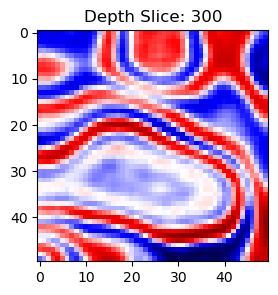

In [14]:
plt.figure(figsize=(3,3))
plt.title('Depth Slice: 300')
plt.imshow(seismic[...,300], cmap=plt.cm.seismic)
plt.show()